# Local coherence plot

This notebook recreates the cohrence plots between the strain and PEM channels using local, compressed data that we have copied from the LIGo cluster.

See /home/tom.kimpson/ANC/data/compressed on the cluster for the origin of the data 

---

In [1]:
from gwpy.timeseries import TimeSeries
import numpy as np 


import matplotlib.pyplot as plt 
import scienceplots
plt.style.use('science')

In [5]:
import glob 
pem_files = glob.glob('../../data/compressed_data_for_coherence/compressed/pem*')
strain_file = '../../data/compressed_data_for_coherence/compressed/strain_channel_data.npy' 

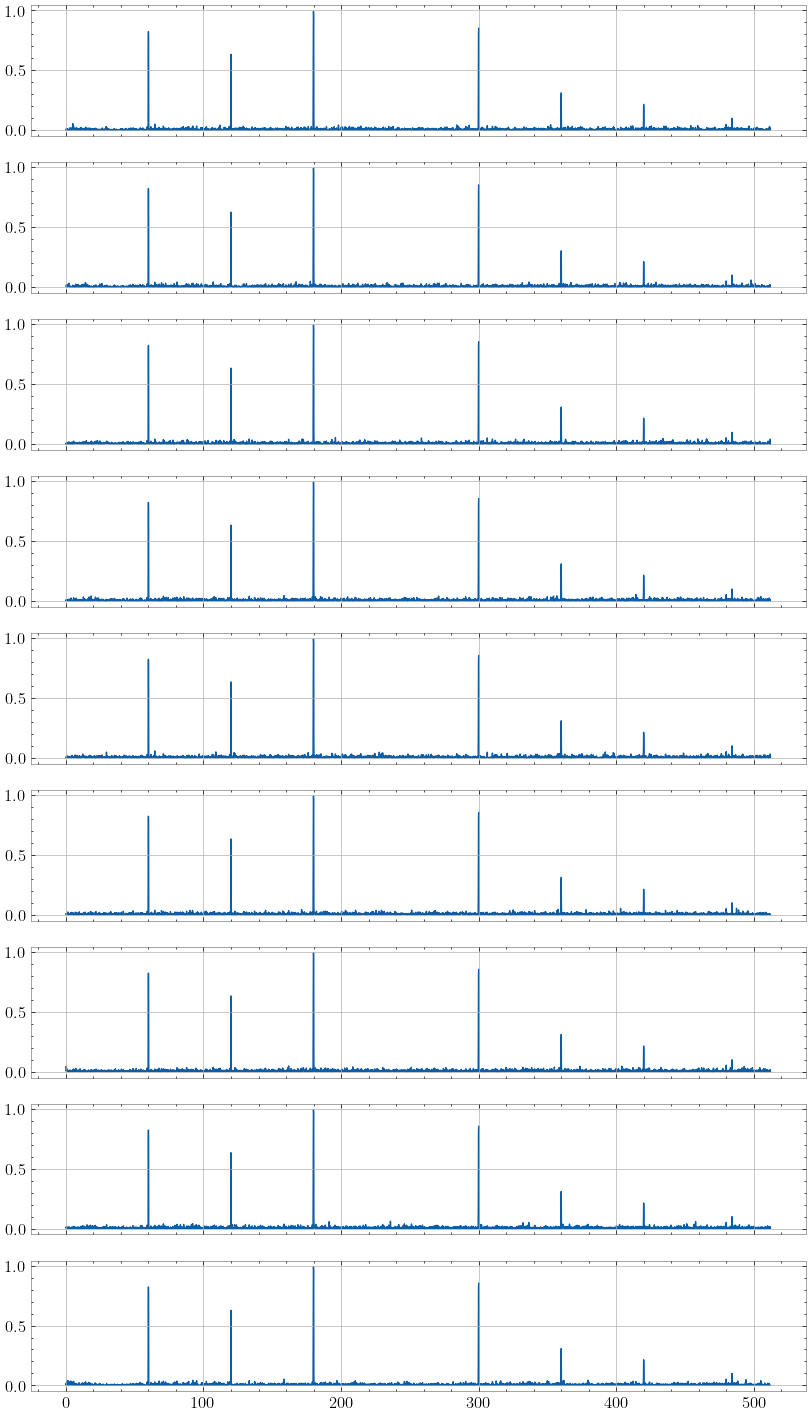

In [35]:
from gwpy.timeseries import TimeSeries

#Setup the figure
num_pem_channels = len(pem_files)
fig, axes = plt.subplots(nrows=num_pem_channels, ncols=1, figsize=(10,18),sharex=True)

#Load the strain data
data = np.load(strain_file)
hoft = TimeSeries(data=data[:,1],times=data[:,0])


for i in range(num_pem_channels):

    data_1 = np.load(pem_files[i])
    acc = TimeSeries(data_1[:,1],times=data_1[:,0])


    coh = hoft.coherence(acc,fftlength=8)
    coherence_frequencies = np.array(coh.frequencies)
    coherence_values = np.array(coh)

    ax = axes[i]
    ax.plot(coherence_frequencies,coherence_values)



plt.show()